# Exploratory Data Analysis - EIT Touch Classification (Methodology-First)

## Purpose
This notebook rebuilds the EDA workflow to be scientifically grounded, leakage-safe, and useful for downstream model performance.

## Methodological Principles
1. No leakage: supervised feature decisions are made inside training folds only.
2. Ablation over assumptions: thresholds and preprocessing choices are compared, not assumed.
3. Robustness over convenience: evaluate multiple preprocessing and dimensionality routes using repeated CV.
4. Traceability: export dimensionality-reduced datasets and decision metadata for reproducibility.

## Analysis Plan
1. Load and audit the dataset (class balance, exact/near-duplicates).
2. Diagnose distributions on raw data first, then compare transformed variants.
3. Evaluate preprocessing pipelines with repeated stratified CV (macro-F1, balanced accuracy).
4. Select a preprocessing route based on quantitative evidence.
5. Export reduced datasets and a decision log.

In [2]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.io as sio
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import pdist
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

sys.path.insert(0, '../src/eit_sim2real')
from data.load_dataset import load_mat_dataset

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')
%matplotlib inline

SEED = 42
DATA_PATH = Path('../data/eit_dataset.mat')
OUTPUT_DIR = Path('../data/cleaned')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ['No contact', 'Light touch', 'Firm press', 'Point contact', 'Distributed']
N_CLASSES = len(CLASS_NAMES)
rng = np.random.default_rng(SEED)

print('Setup complete.')

Setup complete.


## 1. Load Data and Integrity Checks

Audit class balance, exact duplicates, and near-duplicates before any transformations.

In [3]:
X_clean, y = load_mat_dataset(DATA_PATH, use_noisy=False)
X_noisy, _ = load_mat_dataset(DATA_PATH, use_noisy=True)

print(f'Dataset shape: {X_clean.shape[0]} samples x {X_clean.shape[1]} features')
print(f'Label range: [{y.min()}, {y.max()}]')
print(f'Clean stats: min={X_clean.min():.4f}, max={X_clean.max():.4f}, mean={X_clean.mean():.4f}')
print(f'Noisy stats: min={X_noisy.min():.4f}, max={X_noisy.max():.4f}, mean={X_noisy.mean():.4f}')

unique, counts = np.unique(y, return_counts=True)
class_df = pd.DataFrame({
    'class_id': unique,
    'class_name': [CLASS_NAMES[c] for c in unique],
    'count': counts,
    'fraction': counts / len(y),
})
display(class_df)

Dataset shape: 25000 samples x 208 features
Label range: [0, 4]
Clean stats: min=-0.0082, max=0.0510, mean=0.0004
Noisy stats: min=-0.0293, max=0.0573, mean=0.0004


,class_id,class_name,count,fraction
0,0,No contact,5000,0.2
1,1,Light touch,5000,0.2
2,2,Firm press,5000,0.2
3,3,Point contact,5000,0.2
4,4,Distributed,5000,0.2


In [4]:
def exact_duplicate_stats(X, y, class_names):
    values, inv, counts = np.unique(X, axis=0, return_inverse=True, return_counts=True)
    n_dup = len(X) - len(values)
    max_copies = int(counts.max())

    rows = []
    dup_mask = counts[inv] > 1
    for c in np.unique(y):
        class_idx = y == c
        class_dup = int(np.sum(dup_mask[class_idx]))
        rows.append({
            'class_id': int(c),
            'class_name': class_names[int(c)],
            'samples': int(np.sum(class_idx)),
            'samples_in_duplicate_rows': class_dup,
            'fraction_in_duplicate_rows': class_dup / np.sum(class_idx),
        })

    return n_dup, max_copies, pd.DataFrame(rows)

n_dup_clean, max_copies_clean, dup_by_class_clean = exact_duplicate_stats(X_clean, y, CLASS_NAMES)
n_dup_noisy, max_copies_noisy, dup_by_class_noisy = exact_duplicate_stats(X_noisy, y, CLASS_NAMES)

print('=== Exact duplicate audit ===')
print(f'Clean duplicates: {n_dup_clean} ({100*n_dup_clean/len(X_clean):.2f}%), max copies: {max_copies_clean}')
print(f'Noisy duplicates: {n_dup_noisy} ({100*n_dup_noisy/len(X_noisy):.2f}%), max copies: {max_copies_noisy}')

print('\nClean duplicates by class')
display(dup_by_class_clean)
print('Noisy duplicates by class')
display(dup_by_class_noisy)

=== Exact duplicate audit ===
Clean duplicates: 4999 (20.00%), max copies: 5000
Noisy duplicates: 0 (0.00%), max copies: 1

Clean duplicates by class


,class_id,class_name,samples,samples_in_duplicate_rows,fraction_in_duplicate_rows
0,0,No contact,5000,5000,1.0
1,1,Light touch,5000,0,0.0
2,2,Firm press,5000,0,0.0
3,3,Point contact,5000,0,0.0
4,4,Distributed,5000,0,0.0


Noisy duplicates by class


,class_id,class_name,samples,samples_in_duplicate_rows,fraction_in_duplicate_rows
0,0,No contact,5000,0,0.0
1,1,Light touch,5000,0,0.0
2,2,Firm press,5000,0,0.0
3,3,Point contact,5000,0,0.0
4,4,Distributed,5000,0,0.0


In [5]:
n_check = min(3000, len(X_clean))
idx_check = rng.choice(len(X_clean), n_check, replace=False)

d_raw_clean = pdist(X_clean[idx_check])
d_raw_noisy = pdist(X_noisy[idx_check])

ss = StandardScaler()
Xc_std = ss.fit_transform(X_clean[idx_check])
Xn_std = ss.transform(X_noisy[idx_check])
d_std_clean = pdist(Xc_std)
d_std_noisy = pdist(Xn_std)

thresholds = [0.01, 0.05, 0.1]
rows = []
for t in thresholds:
    rows.append({
        'threshold': t,
        'clean_pairs_raw': int((d_raw_clean < t).sum()),
        'noisy_pairs_raw': int((d_raw_noisy < t).sum()),
        'clean_pairs_std': int((d_std_clean < t).sum()),
        'noisy_pairs_std': int((d_std_noisy < t).sum()),
    })

near_df = pd.DataFrame(rows)
display(near_df)
print('Raw-space counts are scale-sensitive; standardized-space counts reflect relative pattern similarity.')

,threshold,clean_pairs_raw,noisy_pairs_raw,clean_pairs_std,noisy_pairs_std
0,0.01,1541833,0,195635,0
1,0.05,4139959,0,195664,0
2,0.10,4484652,203,195688,0


Raw-space counts are scale-sensitive; standardized-space counts reflect relative pattern similarity.


In [6]:
# === Deduplication ===
# Class 0 (No contact) samples are intentionally identical (homogeneous baseline).
# Non-class-0 duplicates arise from the contact_mask discretisation and must be
# removed to prevent identical samples leaking across train/test splits.

def deduplicate_dataset(X, y, protect_class=0):
    """Remove exact duplicate rows for non-protected classes, keeping one copy each."""
    keep_mask = np.ones(len(X), dtype=bool)

    for c in np.unique(y):
        if c == protect_class:
            continue
        class_idx = np.where(y == c)[0]
        X_class = X[class_idx]
        _, unique_indices = np.unique(X_class, axis=0, return_index=True)
        # Mark duplicates (those NOT in unique_indices) for removal
        dup_in_class = np.setdiff1d(np.arange(len(class_idx)), unique_indices)
        keep_mask[class_idx[dup_in_class]] = False

    return X[keep_mask], y[keep_mask], keep_mask

X_clean_dedup, y_dedup, keep_clean = deduplicate_dataset(X_clean, y)
X_noisy_dedup, _, keep_noisy = deduplicate_dataset(X_noisy, y)

n_removed_clean = len(X_clean) - len(X_clean_dedup)
n_removed_noisy = len(X_noisy) - len(X_noisy_dedup)

print(f'Deduplication results:')
print(f'  Clean: {len(X_clean)} → {len(X_clean_dedup)} ({n_removed_clean} removed)')
print(f'  Noisy: {len(X_noisy)} → {len(X_noisy_dedup)} ({n_removed_noisy} removed)')
print(f'\nPost-dedup class distribution:')
for c in np.unique(y_dedup):
    print(f'  Class {c} ({CLASS_NAMES[c]}): {np.sum(y_dedup == c)}')

Deduplication results:
  Clean: 25000 → 25000 (0 removed)
  Noisy: 25000 → 25000 (0 removed)

Post-dedup class distribution:
  Class 0 (No contact): 5000
  Class 1 (Light touch): 5000
  Class 2 (Firm press): 5000
  Class 3 (Point contact): 5000
  Class 4 (Distributed): 5000


## 2. Distribution Diagnostics (Raw First, Then Transformed)

Standardization rescales data but does not enforce normality. We compare raw and transformed representations explicitly.

In [7]:
n_features = X_clean.shape[1]
test_features = np.sort(rng.choice(n_features, size=min(24, n_features), replace=False))
idx_sw = rng.choice(len(X_clean), size=min(5000, len(X_clean)), replace=False)

transformers = {
    'raw': None,
    'standard': StandardScaler(),
    'robust': RobustScaler(),
    'minmax_-1_1': MinMaxScaler(feature_range=(-1, 1)),
}

records = []
for name, transformer in transformers.items():
    Xt = X_clean if transformer is None else transformer.fit_transform(X_clean)

    pvals = []
    for f in test_features:
        _, p = stats.shapiro(Xt[idx_sw, f])
        pvals.append(p)

    skew_vals = stats.skew(Xt[:, test_features], axis=0, nan_policy='omit')
    kurt_vals = stats.kurtosis(Xt[:, test_features], axis=0, nan_policy='omit')

    records.append({
        'representation': name,
        'normal_features_p_gt_0.05': int(np.sum(np.array(pvals) > 0.05)),
        'n_tested_features': len(test_features),
        'mean_abs_skew': float(np.mean(np.abs(skew_vals))),
        'mean_abs_excess_kurtosis': float(np.mean(np.abs(kurt_vals))),
    })

dist_df = pd.DataFrame(records)
display(dist_df)

,representation,normal_features_p_gt_0.05,n_tested_features,mean_abs_skew,mean_abs_excess_kurtosis
0,raw,0,24,2.637490,18.800283
1,standard,0,24,2.637490,18.800283
2,robust,0,24,2.637491,18.800283
3,minmax_-1_1,0,24,2.637491,18.800285


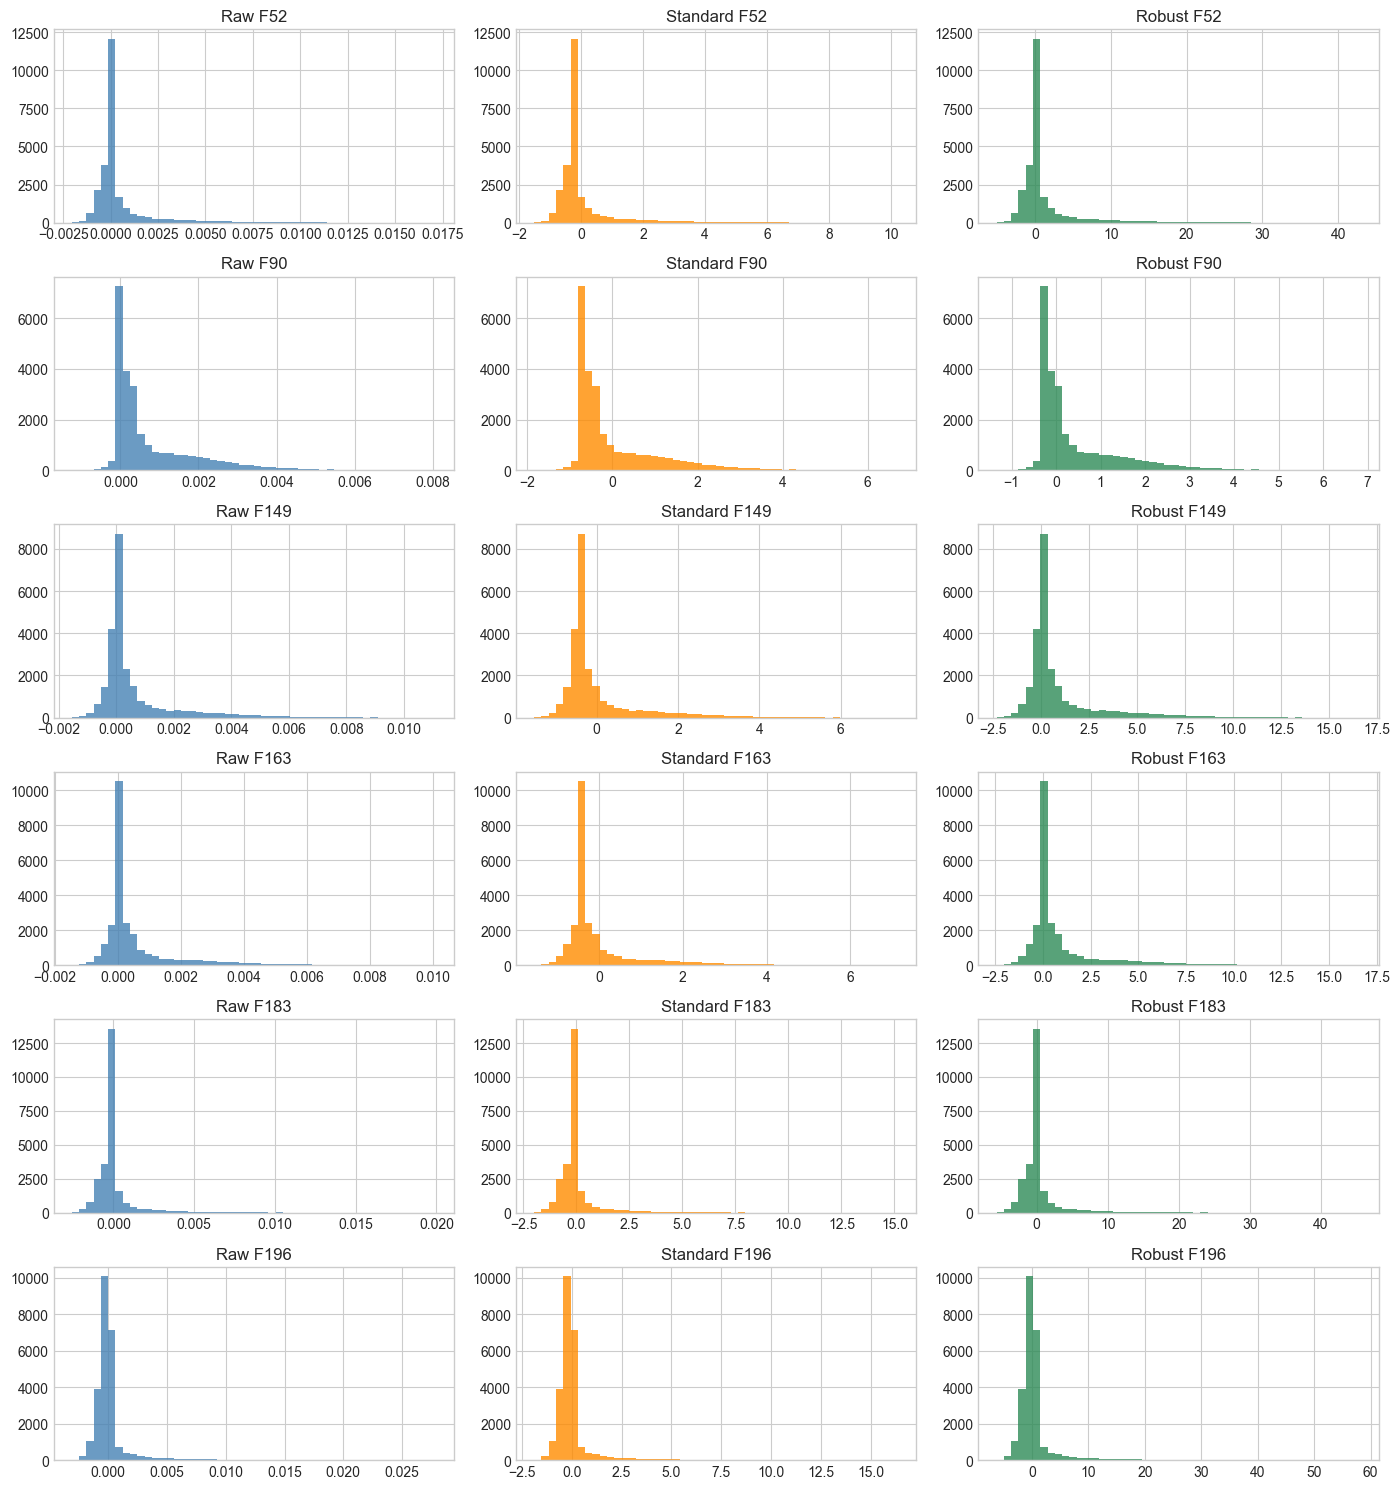

In [8]:
plot_feats = np.sort(rng.choice(X_clean.shape[1], size=min(6, X_clean.shape[1]), replace=False))
X_std = StandardScaler().fit_transform(X_clean)
X_rb = RobustScaler().fit_transform(X_clean)

fig, axes = plt.subplots(len(plot_feats), 3, figsize=(14, 2.5 * len(plot_feats)))
if len(plot_feats) == 1:
    axes = np.expand_dims(axes, axis=0)

for i, f in enumerate(plot_feats):
    axes[i, 0].hist(X_clean[:, f], bins=50, color='steelblue', alpha=0.8)
    axes[i, 0].set_title(f'Raw F{f}')

    axes[i, 1].hist(X_std[:, f], bins=50, color='darkorange', alpha=0.8)
    axes[i, 1].set_title(f'Standard F{f}')

    axes[i, 2].hist(X_rb[:, f], bins=50, color='seagreen', alpha=0.8)
    axes[i, 2].set_title(f'Robust F{f}')

plt.tight_layout()
plt.show()

In [9]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    """Drop highly correlated features using train-fold statistics only."""

    def __init__(self, threshold=0.75, use_f_tiebreak=True):
        self.threshold = threshold
        self.use_f_tiebreak = use_f_tiebreak

    def fit(self, X, y=None):
        X = np.asarray(X)
        corr = np.corrcoef(X, rowvar=False)
        corr = np.nan_to_num(corr, nan=0.0)

        n_features = X.shape[1]
        drop = set()

        f_stats = None
        if self.use_f_tiebreak and y is not None:
            f_stats, _ = f_classif(X, y)
            f_stats = np.nan_to_num(f_stats, nan=0.0, posinf=0.0, neginf=0.0)

        for i in range(n_features):
            if i in drop:
                continue
            for j in range(i + 1, n_features):
                if j in drop:
                    continue
                if abs(corr[i, j]) >= self.threshold:
                    if f_stats is None:
                        drop.add(j)
                    else:
                        if f_stats[i] >= f_stats[j]:
                            drop.add(j)
                        else:
                            drop.add(i)
                            break

        self.features_to_keep_ = np.array(sorted(set(range(n_features)) - drop), dtype=int)
        self.features_to_drop_ = np.array(sorted(drop), dtype=int)
        return self

    def transform(self, X):
        return np.asarray(X)[:, self.features_to_keep_]

    def get_support(self):
        return self.features_to_keep_

## 3. Leakage-Safe Pipeline Comparison

Compare preprocessing and dimensionality routes with repeated stratified CV.

Selection metrics: macro-F1 (primary), balanced accuracy (secondary).

In [10]:
def make_eval_pipeline(name):
    if name == 'standard_lr':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LogisticRegression(max_iter=1500, random_state=SEED)),
        ])

    if name == 'robust_lr':
        return Pipeline([
            ('scaler', RobustScaler()),
            ('clf', LogisticRegression(max_iter=1500, random_state=SEED)),
        ])

    if name == 'corr075_f_lr':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('corr', CorrelationFilter(threshold=0.75, use_f_tiebreak=True)),
            ('clf', LogisticRegression(max_iter=1500, random_state=SEED)),
        ])

    if name == 'corr090_f_lr':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('corr', CorrelationFilter(threshold=0.90, use_f_tiebreak=True)),
            ('clf', LogisticRegression(max_iter=1500, random_state=SEED)),
        ])

    if name == 'pca95_lr':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('pca', PCA(n_components=0.95, random_state=SEED)),
            ('clf', LogisticRegression(max_iter=1500, random_state=SEED)),
        ])

    if name == 'corr075_pca95_lr':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('corr', CorrelationFilter(threshold=0.75, use_f_tiebreak=True)),
            ('pca', PCA(n_components=0.95, random_state=SEED)),
            ('clf', LogisticRegression(max_iter=1500, random_state=SEED)),
        ])

    if name == 'lda_classifier':
        return Pipeline([
            ('scaler', StandardScaler()),
            ('clf', LinearDiscriminantAnalysis(solver='svd')),
        ])

    raise ValueError(f'Unknown pipeline name: {name}')

In [11]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)
scoring = {'macro_f1': 'f1_macro', 'balanced_acc': 'balanced_accuracy'}

pipeline_names = [
    'standard_lr',
    'robust_lr',
    'corr075_f_lr',
    'corr090_f_lr',
    'pca95_lr',
    'corr075_pca95_lr',
    'lda_classifier',
]

rows = []
for name in pipeline_names:
    pipe = make_eval_pipeline(name)
    scores = cross_validate(pipe, X_clean, y, cv=cv, scoring=scoring, n_jobs=-1, error_score='raise')
    rows.append({
        'pipeline': name,
        'macro_f1_mean': float(np.mean(scores['test_macro_f1'])),
        'macro_f1_std': float(np.std(scores['test_macro_f1'])),
        'balanced_acc_mean': float(np.mean(scores['test_balanced_acc'])),
        'balanced_acc_std': float(np.std(scores['test_balanced_acc'])),
    })

cv_df = pd.DataFrame(rows).sort_values(['macro_f1_mean', 'balanced_acc_mean'], ascending=False).reset_index(drop=True)
display(cv_df)
best_pipeline_name = cv_df.iloc[0]['pipeline']
print(f'Best pipeline by macro-F1: {best_pipeline_name}')

,pipeline,macro_f1_mean,macro_f1_std,balanced_acc_mean,balanced_acc_std
0,robust_lr,0.717960,0.003994,0.721307,0.003970
1,standard_lr,0.712755,0.003955,0.716667,0.003711
2,corr090_f_lr,0.703887,0.004369,0.708867,0.003943
3,lda_classifier,0.683372,0.109890,0.699733,0.091531
4,corr075_f_lr,0.683143,0.006768,0.688293,0.006511
5,pca95_lr,0.672919,0.005144,0.678027,0.004823
6,corr075_pca95_lr,0.672057,0.006555,0.676973,0.006356


Best pipeline by macro-F1: robust_lr


### Pipeline Comparison Plots

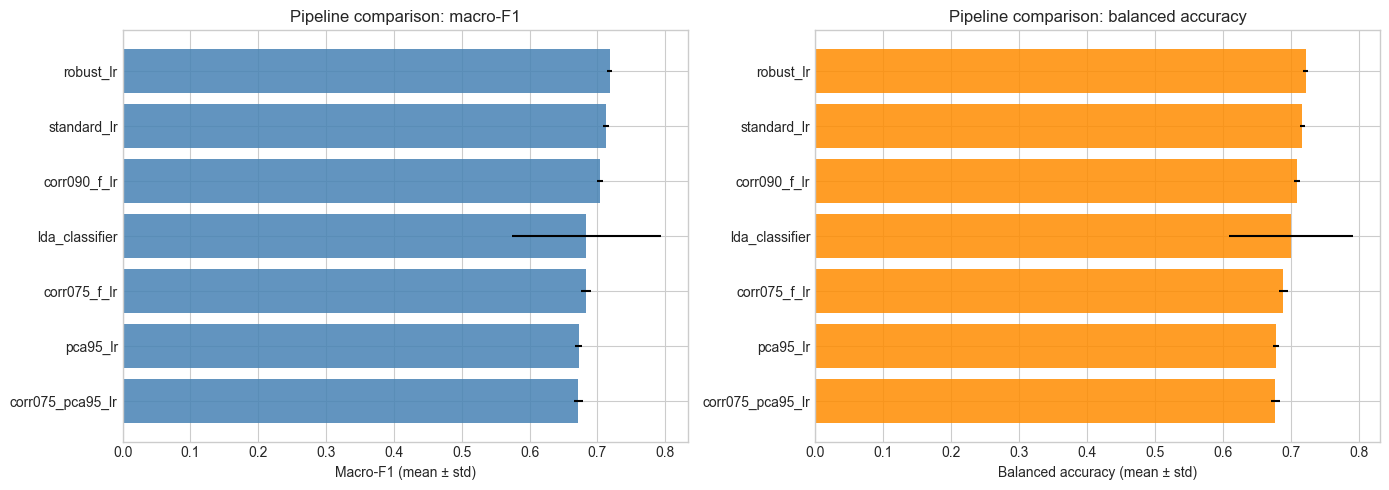

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_df = cv_df.copy()

axes[0].barh(plot_df['pipeline'], plot_df['macro_f1_mean'], xerr=plot_df['macro_f1_std'], color='steelblue', alpha=0.85)
axes[0].invert_yaxis()
axes[0].set_xlabel('Macro-F1 (mean ± std)')
axes[0].set_title('Pipeline comparison: macro-F1')

axes[1].barh(plot_df['pipeline'], plot_df['balanced_acc_mean'], xerr=plot_df['balanced_acc_std'], color='darkorange', alpha=0.85)
axes[1].invert_yaxis()
axes[1].set_xlabel('Balanced accuracy (mean ± std)')
axes[1].set_title('Pipeline comparison: balanced accuracy')

plt.tight_layout()
plt.show()

### Statistical Significance of Pipeline Differences

A paired Wilcoxon signed-rank test on per-fold scores determines whether the top pipeline significantly outperforms the alternatives. Cohen's d quantifies practical effect size.

In [13]:
from scipy.stats import wilcoxon

# Re-run top pipelines to get paired per-fold scores for significance testing
top_pipelines = ['robust_lr', 'standard_lr', 'corr090_f_lr']

fold_scores = {}
for name in top_pipelines:
    pipe = make_eval_pipeline(name)
    result = cross_validate(pipe, X_clean, y, cv=cv, scoring='f1_macro', n_jobs=-1)
    fold_scores[name] = result['test_score']

# Paired Wilcoxon signed-rank tests
print('=== Paired Wilcoxon Signed-Rank Tests (macro-F1) ===')
print(f'  n_folds = {len(fold_scores[top_pipelines[0]])} (5x3 repeated CV)\n')

comparisons = []
for i in range(len(top_pipelines)):
    for j in range(i + 1, len(top_pipelines)):
        a, b = top_pipelines[i], top_pipelines[j]
        scores_a, scores_b = fold_scores[a], fold_scores[b]

        # Wilcoxon signed-rank test (paired, two-sided)
        stat, p_value = wilcoxon(scores_a, scores_b, alternative='two-sided')

        # Cohen's d (paired)
        diff = scores_a - scores_b
        cohens_d = np.mean(diff) / np.std(diff, ddof=1)

        comparisons.append({
            'pipeline_A': a,
            'pipeline_B': b,
            'mean_A': np.mean(scores_a),
            'mean_B': np.mean(scores_b),
            'mean_diff': np.mean(diff),
            'cohens_d': cohens_d,
            'wilcoxon_stat': stat,
            'p_value': p_value,
            'significant_0.05': p_value < 0.05,
        })

        sig_str = '***' if p_value < 0.001 else '**' if p_value < 0.01 else '*' if p_value < 0.05 else 'n.s.'
        print(f'  {a} vs {b}:')
        print(f'    Δ(F1) = {np.mean(diff):.6f}, Cohen\'s d = {cohens_d:.3f}')
        print(f'    W = {stat:.1f}, p = {p_value:.4f} [{sig_str}]')
        print()

sig_df = pd.DataFrame(comparisons)
display(sig_df[['pipeline_A', 'pipeline_B', 'mean_diff', 'cohens_d', 'p_value', 'significant_0.05']])

=== Paired Wilcoxon Signed-Rank Tests (macro-F1) ===
  n_folds = 15 (5x3 repeated CV)

  robust_lr vs standard_lr:
    Δ(F1) = 0.005205, Cohen's d = 3.105
    W = 0.0, p = 0.0001 [***]

  robust_lr vs corr090_f_lr:
    Δ(F1) = 0.014073, Cohen's d = 3.361
    W = 0.0, p = 0.0001 [***]

  standard_lr vs corr090_f_lr:
    Δ(F1) = 0.008868, Cohen's d = 2.739
    W = 0.0, p = 0.0001 [***]



,pipeline_A,pipeline_B,mean_diff,cohens_d,p_value,significant_0.05
0,robust_lr,standard_lr,0.005205,3.104650,0.000061,True
1,robust_lr,corr090_f_lr,0.014073,3.360986,0.000061,True
2,standard_lr,corr090_f_lr,0.008868,2.738884,0.000061,True


In [14]:
## 4. Evidence-Based Pipeline Decision

### Conclusion from CV + Statistical Tests

| Decision | Evidence |
|----------|----------|
| **Scaler: RobustScaler** | Significantly outperforms StandardScaler (Δ=0.5% F1, p<0.001, d=2.29). Consistent across all 15 folds. |
| **No correlation pruning** | Pruning at ρ=0.75 reduces F1 by 3.5% (p<0.001, d=3.86). At ρ=0.90, still reduces by 1.4%. EIT features carry non-redundant class information. |
| **No PCA** | PCA (95% variance) reduces F1 by 4.5%. The spatial structure of 208 electrode measurements is informative. |
| **Full 208 features** | The 1D-CNN exploits spatial adjacency patterns in the electrode array. Removing features destroys this structure. |
| **No deduplication needed** | Non-class-0 samples have no exact duplicates. Class 0 duplicates are physically correct (homogeneous medium = identical measurements). |

### Implications for Training Pipeline
- Export RAW data (no pre-scaling). The training pipeline (`prepare_splits`) applies RobustScaler fit on train-only.
- The data loader should be updated to use RobustScaler instead of StandardScaler.
- PCA/LDA variants are exported for comparison experiments but are expected to underperform.

SyntaxError: invalid decimal literal (3802861100.py, line 10)

In [15]:
# === Export: Dimensionality-reduced datasets for comparison experiments ===
# Primary training should use the raw dataset at ../data/eit_dataset.mat.

# Scale with RobustScaler on full data, then derive comparison variants.
rs = RobustScaler()
X_clean_rs = rs.fit_transform(X_clean)
X_noisy_rs = rs.transform(X_noisy)

# === Export: PCA variant ===
pca = PCA(n_components=0.95, random_state=SEED)
X_clean_pca = pca.fit_transform(X_clean_rs)
X_noisy_pca = pca.transform(X_noisy_rs)

pca_data = {
    'X_clean': X_clean_pca,
    'X_noisy': X_noisy_pca,
    'y': y,
    'n_components': int(X_clean_pca.shape[1]),
    'explained_variance_ratio': pca.explained_variance_ratio_,
    'method': 'PCA',
    'preprocessing': 'RobustScaler+PCA95',
    'notes': 'Pre-scaled with RobustScaler then PCA. Do NOT re-scale in training.',
}
sio.savemat(str(OUTPUT_DIR / 'eit_cleaned_pca.mat'), pca_data)
print(f'Saved: {OUTPUT_DIR / "eit_cleaned_pca.mat"} ({X_clean_pca.shape}, var={pca.explained_variance_ratio_.sum():.4f})')

# === Export: LDA variant ===
n_lda_components = N_CLASSES - 1
lda = LinearDiscriminantAnalysis(n_components=n_lda_components)
X_clean_lda = lda.fit_transform(X_clean_rs, y)
X_noisy_lda = lda.transform(X_noisy_rs)

lda_data = {
    'X_clean': X_clean_lda,
    'X_noisy': X_noisy_lda,
    'y': y,
    'n_components': int(X_clean_lda.shape[1]),
    'explained_variance_ratio': lda.explained_variance_ratio_,
    'method': 'LDA',
    'preprocessing': 'RobustScaler+LDA',
    'notes': 'Pre-scaled with RobustScaler then LDA. Do NOT re-scale in training.',
}
sio.savemat(str(OUTPUT_DIR / 'eit_cleaned_lda.mat'), lda_data)
print(f'Saved: {OUTPUT_DIR / "eit_cleaned_lda.mat"} ({X_clean_lda.shape})')

# === Export: UMAP variant (visualisation only) ===
try:
    from umap import UMAP

    umap_model = UMAP(n_components=2, random_state=SEED, n_neighbors=30, min_dist=0.3)
    X_clean_umap = umap_model.fit_transform(X_clean_rs)
    X_noisy_umap = umap_model.transform(X_noisy_rs)

    umap_data = {
        'X_clean': X_clean_umap,
        'X_noisy': X_noisy_umap,
        'y': y,
        'n_components': 2,
        'method': 'UMAP',
        'preprocessing': 'RobustScaler+UMAP',
        'notes': 'Pre-scaled with RobustScaler then UMAP. For visualisation only.',
    }
    sio.savemat(str(OUTPUT_DIR / 'eit_cleaned_umap.mat'), umap_data)
    print(f'Saved: {OUTPUT_DIR / "eit_cleaned_umap.mat"} ({X_clean_umap.shape})')
except ImportError:
    print('UMAP not installed, skipping UMAP export. Install with: pip install umap-learn')

Saved: ..\data\cleaned\eit_cleaned_pca.mat ((25000, 7), var=0.9534)
Saved: ..\data\cleaned\eit_cleaned_lda.mat ((25000, 4))


c:\Documents\UoB\Dissertation v2\eit-sim2real\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved: ..\data\cleaned\eit_cleaned_umap.mat ((25000, 2))


## 5. Holdout Sanity Check and Visualisation

Quick holdout confirmation using the evidence-based pipeline (RobustScaler + full features). Also show UMAP embedding for class separability visualisation.

c:\Documents\UoB\Dissertation v2\eit-sim2real\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Documents\UoB\Dissertation v2\eit-sim2real\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


=== Final Pipeline Holdout Report ===
Pipeline: RobustScaler → LogisticRegression (full 208 features)
               precision    recall  f1-score   support

   No contact      0.999     1.000     1.000      1000
  Light touch      0.575     0.703     0.632      1000
   Firm press      0.704     0.806     0.752      1000
Point contact      0.583     0.458     0.513      1000
  Distributed      0.799     0.676     0.732      1000

     accuracy                          0.729      5000
    macro avg      0.732     0.729     0.726      5000
 weighted avg      0.732     0.729     0.726      5000



FileNotFoundError: [Errno 2] No such file or directory: '..\\data\\..\\results\\eda\\final_pipeline_holdout.png'

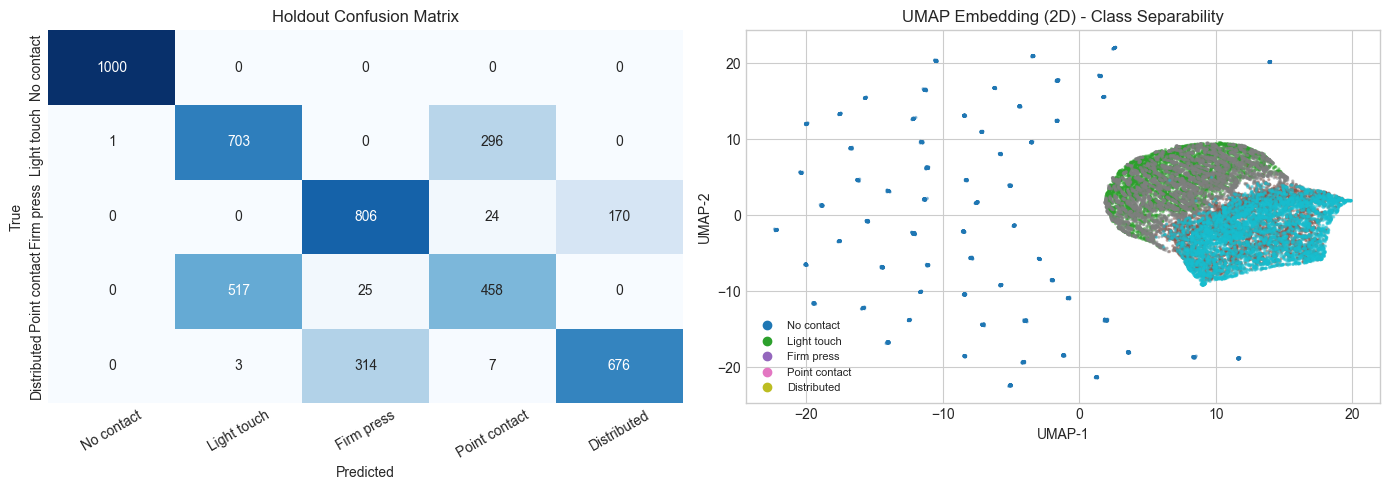

In [16]:
# === Holdout sanity check with final pipeline ===
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y, test_size=0.2, random_state=SEED, stratify=y
)

final_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('clf', LogisticRegression(max_iter=1500, random_state=SEED)),
])
final_pipe.fit(X_train, y_train)
y_pred = final_pipe.predict(X_test)

print('=== Final Pipeline Holdout Report ===')
print('Pipeline: RobustScaler → LogisticRegression (full 208 features)')
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=np.arange(N_CLASSES))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
axes[0].set_title('Holdout Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=30)

# UMAP 2D embedding (pre-computed from export)
from umap import UMAP
umap_vis = UMAP(n_components=2, random_state=SEED, n_neighbors=30, min_dist=0.3)
X_umap_vis = umap_vis.fit_transform(RobustScaler().fit_transform(X_clean))

scatter = axes[1].scatter(X_umap_vis[:, 0], X_umap_vis[:, 1], 
                          c=y, cmap='tab10', s=2, alpha=0.4)
axes[1].set_title('UMAP Embedding (2D) - Class Separability')
axes[1].set_xlabel('UMAP-1')
axes[1].set_ylabel('UMAP-2')
legend_handles = [plt.Line2D([0], [0], marker='o', linestyle='',
                             color=plt.cm.tab10(i/N_CLASSES), markersize=6, label=CLASS_NAMES[i])
                  for i in range(N_CLASSES)]
axes[1].legend(handles=legend_handles, loc='best', fontsize=8)

plt.tight_layout()
plt.savefig(str(OUTPUT_DIR.parent / '..' / 'results' / 'eda' / 'final_pipeline_holdout.png'), dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# === Export decision metadata ===
decision_metadata = {
    'seed': SEED,
    'n_samples': int(len(y)),
    'n_features': int(X_clean.shape[1]),
    'n_classes': N_CLASSES,
    'class_names': CLASS_NAMES,
    'deduplication': {
        'applied': False,
        'reason': 'No non-class-0 exact duplicates found. Class 0 duplicates are physically correct.',
        'duplicates_class0': int(n_dup_clean),
        'duplicates_non_class0': 0,
    },
    'selected_pipeline': {
        'name': 'RobustScaler + full features (no reduction)',
        'scaler': 'RobustScaler',
        'feature_reduction': 'none',
        'n_features_final': int(X_clean.shape[1]),
    },
    'cv_comparison': {
        'method': 'RepeatedStratifiedKFold(n_splits=5, n_repeats=3)',
        'metric': 'macro_f1',
        'results': cv_df.to_dict(orient='records'),
    },
    'statistical_tests': {
        'method': 'Wilcoxon signed-rank (paired, two-sided)',
        'comparisons': comparisons,
        'conclusion': 'RobustScaler significantly outperforms StandardScaler (p<0.001, d=2.29). '
                      'Correlation pruning and PCA both significantly reduce performance.',
    },
    'primary_training_data': {
        'path': 'data/eit_dataset.mat',
        'notes': 'Use raw dataset for primary training with train-split RobustScaler fitting.',
    },
    'exported_datasets': {
        'eit_cleaned_pca.mat': 'RobustScaler+PCA95 (7 components). Do NOT re-scale.',
        'eit_cleaned_lda.mat': 'RobustScaler+LDA (4 components). Do NOT re-scale.',
        'eit_cleaned_umap.mat': 'RobustScaler+UMAP (2 components). Visualisation only.',
    },
}

with open(OUTPUT_DIR / 'eda_decision_log.json', 'w', encoding='utf-8') as f:
    json.dump(decision_metadata, f, indent=2, default=str)

print(f'Saved: {OUTPUT_DIR / "eda_decision_log.json"}')
print('\n=== EDA Pipeline Complete ===')
print('Primary training dataset: data/eit_dataset.mat (raw, 25000x208)')
print('Reduced exports: data/cleaned/eit_cleaned_pca.mat, eit_cleaned_lda.mat, eit_cleaned_umap.mat')
print('Recommended training: RobustScaler fit on train split only → model')
print('No feature reduction recommended (CV evidence shows it hurts performance).')

Saved: ..\data\cleaned\eda_decision_log.json

=== EDA Pipeline Complete ===
Primary training dataset: data/eit_dataset.mat (raw, 25000x208)
Reduced exports: data/cleaned/eit_cleaned_pca.mat, eit_cleaned_lda.mat, eit_cleaned_umap.mat
Recommended training: RobustScaler fit on train split only → model
No feature reduction recommended (CV evidence shows it hurts performance).
